In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
import sklearn.metrics as sm 
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, fcluster  # Import the fcluster function
from scipy.cluster.hierarchy import dendrogram
from scipy.spatial import distance


In [4]:
# Loading the data
all4_gtsB_gtsD_clusters = pd.read_csv('categorical_4fold_gtsB_gtsD_consensus.csv')
print(all4_gtsB_gtsD_clusters.shape)
print(all4_gtsB_gtsD_clusters.head())
print(all4_gtsB_gtsD_clusters.isnull().sum())
print(all4_gtsB_gtsD_clusters.shape)
print(all4_gtsB_gtsD_clusters.info())

(122, 11)
   gene  cluster      variable   Cla/Mod   Mod/Cla  Global   p.value  \
0  gtsB        1  Amino acid=A  0.766667  0.418182    0.30  0.055800   
1  gtsB        1  Amino acid=G  0.041667  0.018182    0.24  0.000117   
2  gtsB        1  Amino acid=P  0.923077  0.218182    0.13  0.051824   
3  gtsB        1  Amino acid=T  0.166667  0.036364    0.12  0.056297   
4  gtsB        1  Amino acid=V  0.809524  0.309091    0.21  0.071195   

     v.test  n_level  n_in_cluster  n_cluster_level  
0  1.912592       30            55               23  
1 -3.851821       24            55                1  
2  1.944595       13            55               12  
3 -1.908730       12            55                2  
4  1.804230       21            55               17  
gene               0
cluster            0
variable           0
Cla/Mod            0
Mod/Cla            0
Global             0
p.value            0
v.test             0
n_level            0
n_in_cluster       0
n_cluster_level    0
dt

In [5]:
##filtering by gene, first gtsB

filtered_gtsBclusters4all = all4_gtsB_gtsD_clusters[all4_gtsB_gtsD_clusters['gene'] == 'gtsB']  
print(filtered_gtsBclusters4all.shape)

(42, 11)


In [8]:
# color palette with 16 distinct colors
c16=  [
    "dodgerblue",  # Replace with "dodgerblue2" if necessary
    "#E31A1C",      # Red
    "green",        # Replace with "green4" if necessary
    "#6A3D9A",      # Purple
    "#FF7F00",      # Orange
    "deeppink",     # Replace with "deeppink1" if necessary
    "gold",
    "skyblue",      # Replace with "skyblue2" if necessary
    "#FB9A99",      # Light pink
    "blue",
    "#CAB2D6",      # Light purple
    "#FDBF6F",      # Light orange
    "black",
    "khaki",
    "maroon",
    "orchid"]

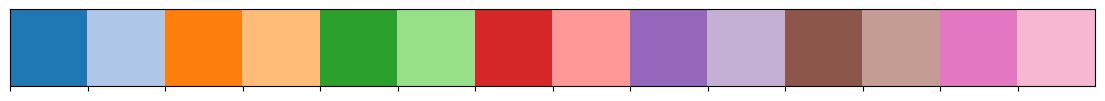

In [9]:
# color palette with 14 distinct colors
colors = sns.color_palette("tab20", 14)

# Optionally, you can visualize the palette
sns.palplot(colors)

In [10]:
##n sizes per cluster gtsB
n_number= [55,24,21]


C:\Users\user\AppData\Local\Temp\ipykernel_5256\1198943829.py:5: UserWarning: The palette list has more values (16) than needed (14), which may not be intended.
  sns.barplot(data=filtered_gtsBclusters4all, x='cluster', y='v.test', hue='variable', palette=c16, linewidth=0.5 , errorbar=None)


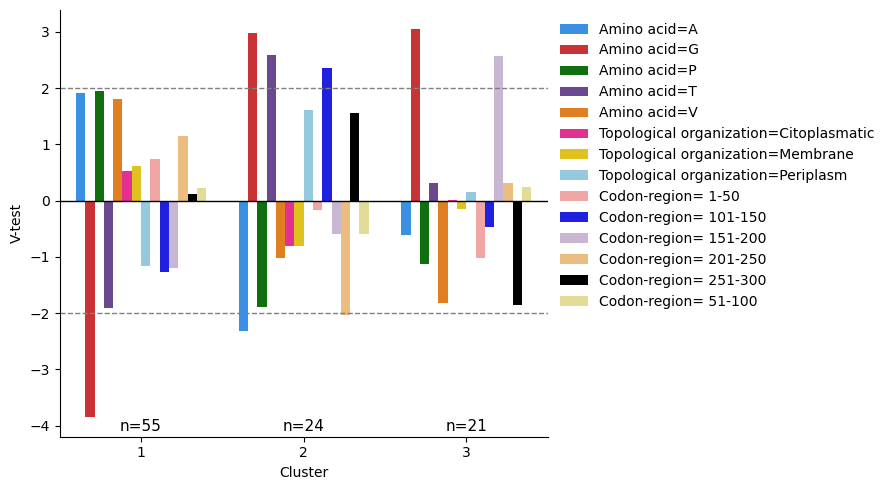

In [11]:
fig = plt.figure(figsize=(9, 5))


# Create the bar plot
sns.barplot(data=filtered_gtsBclusters4all, x='cluster', y='v.test', hue='variable', palette=c16, linewidth=0.5 , errorbar=None)

# Add n number under x-axis labels
for i, v in enumerate(n_number):
    plt.text(i, -4.1, f'n={v}', ha='center', fontsize=11, color='black')
        
        
# Set labels and title
plt.xlabel('Cluster')
plt.ylabel('V-test')
plt.title('')



# Set legend position to the right without overlapping
plt.legend(frameon=False,loc='upper left', bbox_to_anchor=(1, 1), title='')

# Add horizontal lines at Y=2 and Y=-2
plt.axhline(2, color='gray', linestyle='--', linewidth=1)
plt.axhline(-2, color='gray', linestyle='--', linewidth=1)
# Add a black line at y=0
plt.axhline(0, color='black', linewidth=1)

# Removing borders around the graph
sns.despine()

# Removing legend border
plt.legend(frameon=False, bbox_to_anchor=(1, 1), fontsize=10)

plt.tight_layout()  # Adjust layout

# Saving the plot to PNG
plt.savefig('gtsB_qualitative_consensus_4fold_08.png', dpi=1000)
plt.show()  
    

In [15]:
##filtering by gene, then gtsD

filtered_gtsDclusters4all = all4_gtsB_gtsD_clusters[all4_gtsB_gtsD_clusters['gene'] == 'gtsD']  
print(filtered_gtsDclusters4all.shape)

(80, 11)


In [17]:
##n sizes per cluster gtsD
n_number= [17,33,34,19,29]


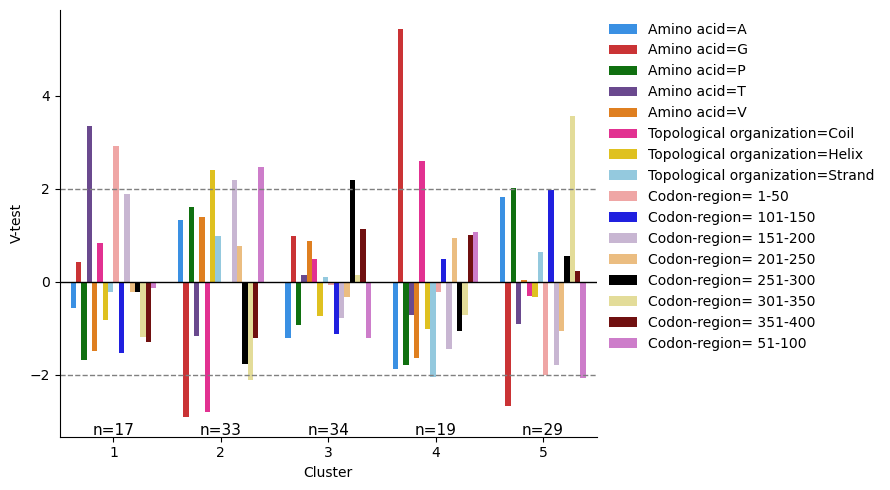

In [18]:
fig = plt.figure(figsize=(9, 5))  

# Create the bar plot
sns.barplot(data=filtered_gtsDclusters4all, x='cluster', y='v.test', hue='variable', palette=c16, linewidth=10 , errorbar=None)

# Set labels and title
plt.xlabel('Cluster')
plt.ylabel('V-test')
plt.title('')

# Add n number under x-axis labels
for i, v in enumerate(n_number):
    plt.text(i, -3.3, f'n={v}', ha='center', fontsize=11, color='black')

# Set legend position to the right without overlapping
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), title='Variables', ncol=1)


# Add a black line at y=0
plt.axhline(0, color='black', linewidth=1)

# Add horizontal lines at Y=2 and Y=-2
plt.axhline(2, color='gray', linestyle='--', linewidth=1)
plt.axhline(-2, color='gray', linestyle='--', linewidth=1)

# Remove borders around the graph
sns.despine()

# Remove legend border
plt.legend(frameon=False, bbox_to_anchor=(1, 1), fontsize=10)  # Position the legend outside the plot



plt.tight_layout()  # Adjust layout

# Save the plot to PNG
plt.savefig('gtsD_qualitative_consensus_4fold_08.png', dpi=1000)
plt.show()  
    